# K-Moda MMM — Fase 2: Exploración y Entendimiento de Datos

**Objetivo:** Entender la estructura, estacionalidad y comportamiento de los datos antes de modelar. Todos los insights de esta fase informan las decisiones de feature engineering de la Fase 3.

**Inputs:** `data/df_ventas_clean.parquet` · `data/df_inversion_clean.parquet` · CSVs raw para desgloses de ciudad, canal y tráfico

**Nota metodológica:** el tráfico (visitas tienda + sesiones web) se analiza aquí como variable mediadora, pero **no entrará al modelo** para evitar endogeneidad.

## 0. Configuración e Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

try:
    from statsmodels.tsa.seasonal import STL
    HAS_STL = True
except ImportError:
    from statsmodels.tsa.seasonal import seasonal_decompose
    HAS_STL = False
    print('STL no disponible, usando seasonal_decompose')

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
    'base': '#D6CFC4',
}
CANAL_COLOR = {
    'Paid Search': KM['paid_search'], 'Social Paid': KM['social_paid'],
    'Video Online': KM['video'],      'Display':     KM['display'],
    'Email CRM':   KM['email_crm'],   'Radio Local': KM['radio'],
    'Exterior':    KM['exterior'],    'Prensa':      KM['prensa'],
}
CIUDAD_COLOR = {
    'Madrid':    '#1A6B8A', 'Barcelona': '#E07B39', 'Valencia': '#8B5E9E',
    'Sevilla':   '#3A9E6F', 'Bilbao':    '#C9A84C',
}
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 1. Carga de datos

In [2]:
# Artefactos Fase 1
df_v = pd.read_parquet(DATA_OUT / 'df_ventas_clean.parquet')
df_i = pd.read_parquet(DATA_OUT / 'df_inversion_clean.parquet')

CANALES = [c for c in df_i.columns if c not in ['semana_inicio','anio','anio_iso','semana_iso']]

# Raw: solo columnas necesarias para desgloses
df_raw = pd.read_csv(
    ROOT / 'ventas_lineas.csv',
    usecols=['fecha_venta','ciudad','canal_venta','categoria','subcategoria',
             'venta_neta_sin_iva_eur','cantidad_unidades'],
    parse_dates=['fecha_venta'],
)
df_raw['semana_inicio'] = (
    df_raw['fecha_venta'] - pd.to_timedelta(df_raw['fecha_venta'].dt.dayofweek, unit='D')
).dt.normalize()

# Trafico diario
df_traf = pd.read_csv(
    ROOT / 'trafico_tienda_web_diario.csv',
    usecols=['fecha','visitas_tienda','sesiones_web','tasa_conversion_tienda_pct',
             'tasa_conversion_web_pct','incidencia_ecommerce_flag'],
    parse_dates=['fecha'],
)
df_traf['semana_inicio'] = (
    df_traf['fecha'] - pd.to_timedelta(df_traf['fecha'].dt.dayofweek, unit='D')
).dt.normalize()
traf_w = df_traf.groupby('semana_inicio').agg(
    visitas_tienda=('visitas_tienda','sum'),
    sesiones_web=('sesiones_web','sum'),
    conv_tienda=('tasa_conversion_tienda_pct','mean'),
    conv_web=('tasa_conversion_web_pct','mean'),
).reset_index()

# DataFrame consolidado para correlaciones
df_eda = df_v.merge(df_i[['semana_inicio']+CANALES], on='semana_inicio', how='left')
df_eda = df_eda.merge(traf_w, on='semana_inicio', how='left')

print(f'df_ventas_clean: {df_v.shape} | df_inv_clean: {df_i.shape}')
print(f'df_eda (consolidado): {df_eda.shape}')
print(f'Canales: {CANALES}')

df_ventas_clean: (262, 20) | df_inv_clean: (262, 12)
df_eda (consolidado): (262, 32)
Canales: ['Display', 'Email CRM', 'Exterior', 'Paid Search', 'Prensa', 'Radio Local', 'Social Paid', 'Video Online']


## 2. Serie temporal de ventas — Señal completa con eventos clave

  Guardado: img\02a_serie_temporal_completa.png


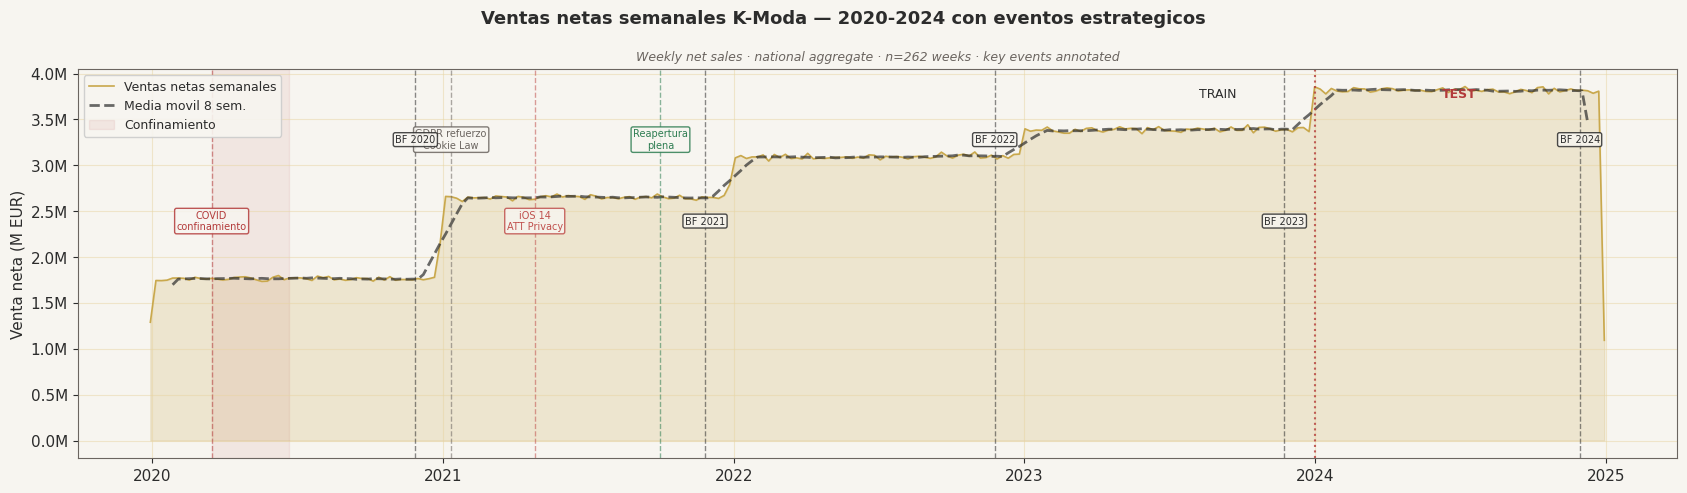

In [3]:
EVENTOS = [
    ('2020-03-16', 'COVID\nconfinamiento',  KM['negative'],  'bottom'),
    ('2021-01-11', 'GDPR refuerzo\nCookie Law', KM['warm_gray'], 'top'),
    ('2021-04-26', 'iOS 14\nATT Privacy', KM['radio'],     'bottom'),
    ('2021-10-01', 'Reapertura\nplena',    KM['positive'],  'top'),
    ('2020-11-27', 'BF 2020', KM['charcoal'], 'top'),
    ('2021-11-26', 'BF 2021', KM['charcoal'], 'bottom'),
    ('2022-11-25', 'BF 2022', KM['charcoal'], 'top'),
    ('2023-11-24', 'BF 2023', KM['charcoal'], 'bottom'),
    ('2024-11-29', 'BF 2024', KM['charcoal'], 'top'),
]

fig, ax = plt.subplots(figsize=(17, 5))
fig.suptitle('Ventas netas semanales K-Moda — 2020-2024 con eventos estrategicos',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

y = df_v['venta_neta_sin_iva_eur'] / 1e6
ax.fill_between(df_v['semana_inicio'], y, alpha=0.2, color=KM['gold'])
ax.plot(df_v['semana_inicio'], y, color=KM['gold'], lw=1.2, label='Ventas netas semanales')
ax.plot(df_v['semana_inicio'], y.rolling(8, center=True).mean(),
        color=KM['charcoal'], lw=2, ls='--', alpha=0.7, label='Media movil 8 sem.')

ax.axvspan(pd.Timestamp('2020-03-16'), pd.Timestamp('2020-06-21'),
           alpha=0.08, color=KM['negative'], label='Confinamiento')
ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], lw=1.5, ls=':', alpha=0.8)
ax.text(pd.Timestamp('2023-09-01'), y.max() * 0.97, 'TRAIN', fontsize=9,
        color=KM['charcoal'], ha='center')
ax.text(pd.Timestamp('2024-07-01'), y.max() * 0.97, 'TEST', fontsize=9,
        color=KM['negative'], ha='center', fontweight='bold')

for fecha, label, color, va in EVENTOS:
    ts = pd.Timestamp(fecha)
    if ts in df_v['semana_inicio'].values or True:
        ax.axvline(ts, color=color, lw=1, ls='--', alpha=0.55)
        y_txt = y.max() * (0.62 if va == 'bottom' else 0.85)
        ax.text(ts, y_txt, label, fontsize=7, color=color, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc=KM['off_white'], ec=color, alpha=0.85))

ax.set_ylabel('Venta neta (M EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.set_title('Weekly net sales · national aggregate · n=262 weeks · key events annotated',
             fontsize=9, color=KM['warm_gray'], style='italic')
plt.tight_layout()
save_fig('02a_serie_temporal_completa')
plt.show()

## 3. Descomposicion estacional STL

STL (Seasonal-Trend decomposition using LOESS) separa la serie en tres componentes: **tendencia**, **estacionalidad anual** (periodo=52 semanas) y **residuo**. El residuo es lo que el modelo MMM intentara explicar ademas de la estacionalidad.

  Guardado: img\02b_descomposicion_stl.png


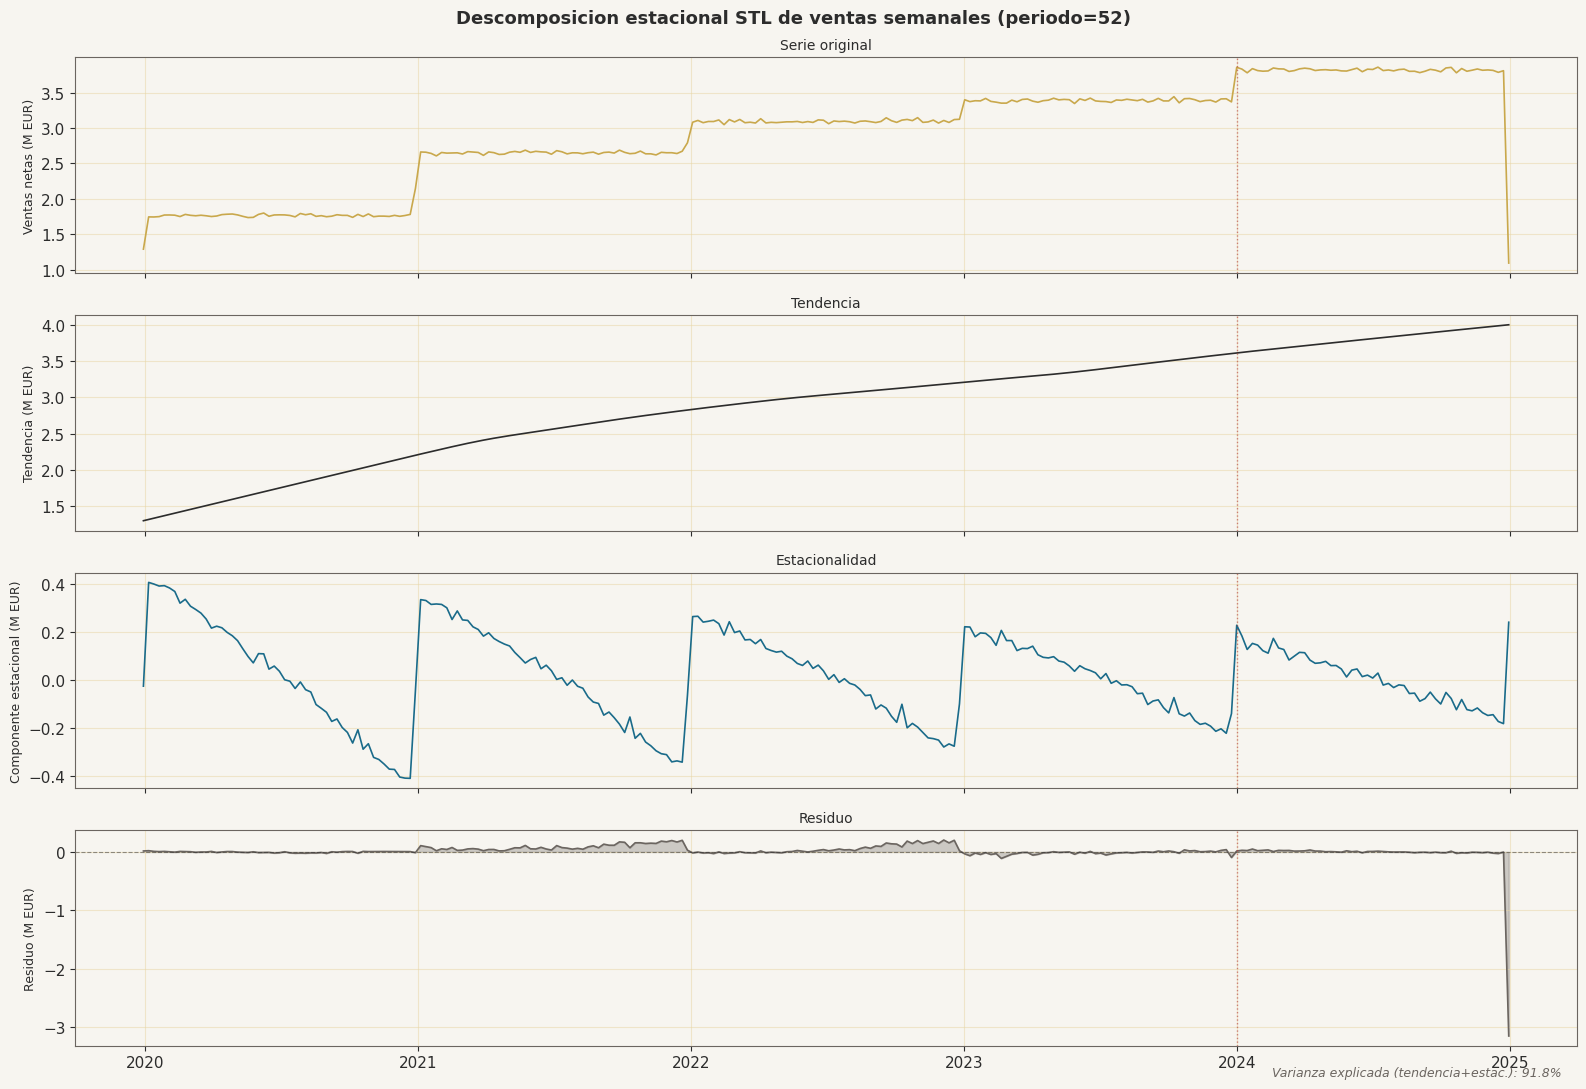

Varianza explicada por tendencia+estacionalidad: 91.8%
Varianza residual (a explicar por el MMM):       8.2%


In [4]:
y_series = df_v.set_index('semana_inicio')['venta_neta_sin_iva_eur'] / 1e6

if HAS_STL:
    stl = STL(y_series, period=52, robust=True)
    res = stl.fit()
    trend    = res.trend
    seasonal = res.seasonal
    resid    = res.resid
else:
    res = seasonal_decompose(y_series, model='additive', period=52, extrapolate_trend='freq')
    trend    = res.trend
    seasonal = res.seasonal
    resid    = res.resid

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Descomposicion estacional STL de ventas semanales (periodo=52)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

componentes = [
    (y_series,  'Serie original',    KM['gold'],     'Ventas netas (M EUR)'),
    (trend,     'Tendencia',         KM['charcoal'], 'Tendencia (M EUR)'),
    (seasonal,  'Estacionalidad',    KM['paid_search'], 'Componente estacional (M EUR)'),
    (resid,     'Residuo',           KM['warm_gray'],'Residuo (M EUR)'),
]
for ax, (serie, titulo, color, ylabel) in zip(axes, componentes):
    ax.plot(serie.index, serie.values, color=color, lw=1.2)
    if titulo == 'Residuo':
        ax.axhline(0, color=KM['charcoal'], lw=0.8, ls='--', alpha=0.5)
        ax.fill_between(serie.index, serie.values, 0, alpha=0.3, color=color)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(titulo, fontsize=10, color=KM['charcoal'])
    ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], lw=1, ls=':', alpha=0.6)

# Fuerza del residuo como % de la varianza total
var_explained = 1 - resid.dropna().var() / y_series.var()
fig.text(0.98, 0.01, f'Varianza explicada (tendencia+estac.): {var_explained*100:.1f}%',
         ha='right', fontsize=9, color=KM['warm_gray'], style='italic')

plt.tight_layout()
save_fig('02b_descomposicion_stl')
plt.show()

print(f'Varianza explicada por tendencia+estacionalidad: {var_explained*100:.1f}%')
print(f'Varianza residual (a explicar por el MMM):       {(1-var_explained)*100:.1f}%')

## 4. Estacionalidad por mes y por semana del anio

  Guardado: img\02c_estacionalidad_mes_semana.png


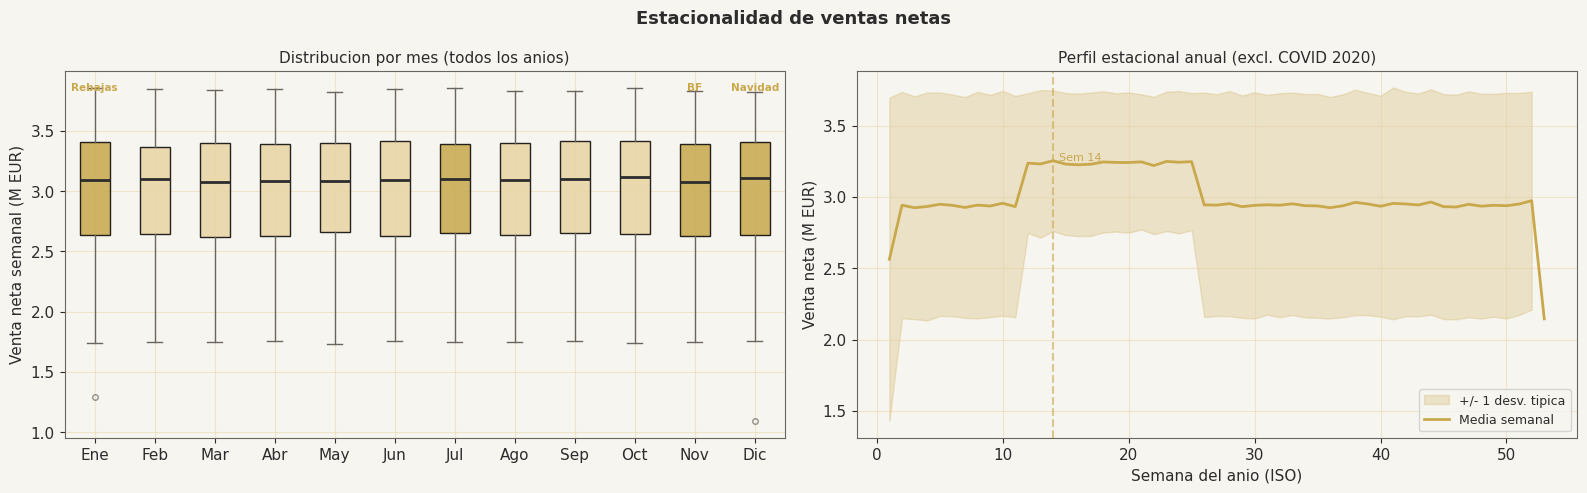

In [5]:
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Estacionalidad de ventas netas', fontsize=13, fontweight='bold', color=KM['charcoal'])

# Por mes — boxplot
ax = axes[0]
datos_mes = [df_v[df_v['mes'] == m]['venta_neta_sin_iva_eur'].values / 1e6 for m in range(1, 13)]
bp = ax.boxplot(datos_mes, patch_artist=True, medianprops=dict(color=KM['charcoal'], lw=2),
                whiskerprops=dict(color=KM['warm_gray']), capprops=dict(color=KM['warm_gray']),
                flierprops=dict(marker='o', color=KM['warm_gray'], alpha=0.4, ms=4))
for patch, m in zip(bp['boxes'], range(1, 13)):
    intensidad = (m in [1, 7, 11, 12])  # Rebajas, verano, BF, Navidad
    patch.set_facecolor(KM['gold'] if intensidad else KM['gold_light'])
    patch.set_alpha(0.85)
ax.set_xticklabels(MESES)
ax.set_ylabel('Venta neta semanal (M EUR)')
ax.set_title('Distribucion por mes (todos los anios)', fontsize=11)
# Marcar meses clave
for m, label in [(1,'Rebajas'), (11,'BF'), (12,'Navidad')]:
    ax.text(m, ax.get_ylim()[1]*0.96, label, ha='center', fontsize=7.5,
            color=KM['gold'], fontweight='bold')

# Por semana del anio — media con banda de confianza (excluyendo 2020 COVID)
ax2 = axes[1]
df_no_covid = df_v[~((df_v['anio'] == 2020) & (df_v['semana_iso'].between(12, 25)))]
sem_stats = df_no_covid.groupby('semana_iso')['venta_neta_sin_iva_eur'].agg(['mean','std']).reset_index()
ax2.fill_between(sem_stats['semana_iso'],
                 (sem_stats['mean'] - sem_stats['std']) / 1e6,
                 (sem_stats['mean'] + sem_stats['std']) / 1e6,
                 alpha=0.25, color=KM['gold'], label='+/- 1 desv. tipica')
ax2.plot(sem_stats['semana_iso'], sem_stats['mean'] / 1e6,
         color=KM['gold'], lw=2, label='Media semanal')
ax2.set_xlabel('Semana del anio (ISO)')
ax2.set_ylabel('Venta neta (M EUR)')
ax2.set_title('Perfil estacional anual (excl. COVID 2020)', fontsize=11)
ax2.legend(fontsize=9)
# Marcar picos
pico_sem = sem_stats.loc[sem_stats['mean'].idxmax(), 'semana_iso']
ax2.axvline(pico_sem, color=KM['gold'], lw=1.5, ls='--', alpha=0.6)
ax2.text(pico_sem+0.5, sem_stats['mean'].max()/1e6, f'Sem {pico_sem}',
         fontsize=8, color=KM['gold'])

plt.tight_layout()
save_fig('02c_estacionalidad_mes_semana')
plt.show()

## 5. Impacto diferencial de eventos comerciales

  Guardado: img\02d_impacto_festivos.png


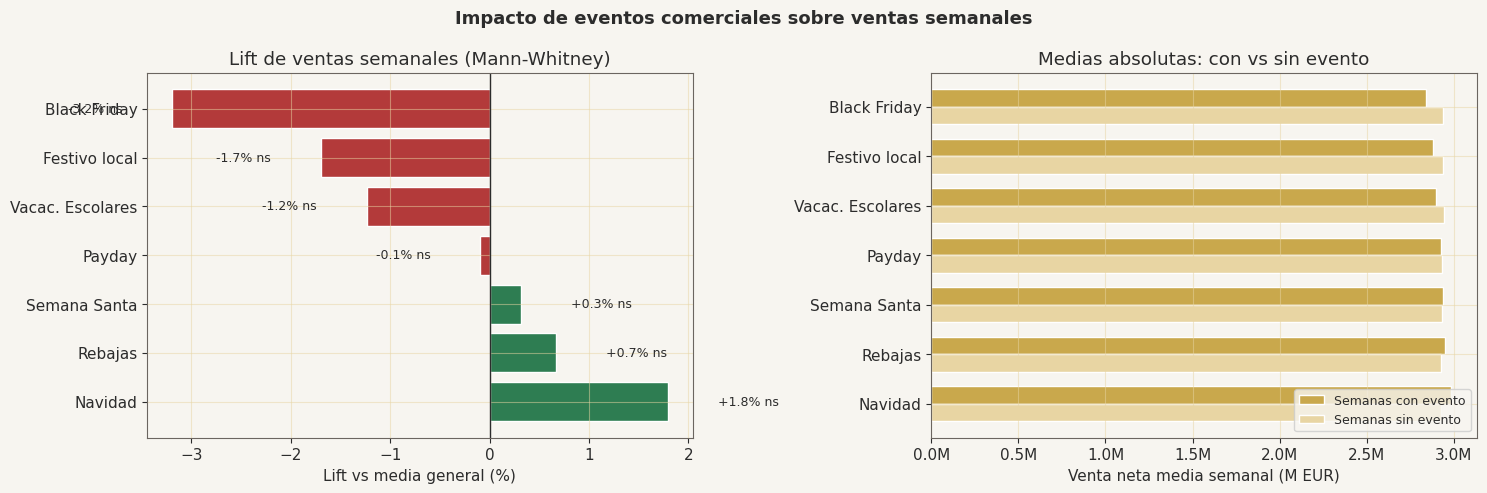

Resultados estadisticos (Mann-Whitney U):
          Evento  Semanas_on  Lift_pct  p_value
         Navidad          21  1.796101 0.748001
         Rebajas          67  0.671028 0.872318
    Semana Santa          10  0.319236 0.944027
          Payday         150 -0.091407 0.907507
Vacac. Escolares          71 -1.237658 0.667761
   Festivo local          35 -1.698690 0.598044
    Black Friday          13 -3.196577 0.484977


In [6]:
# Comparativa de ventas medias en semanas de evento vs semanas normales
flags = {
    'Black Friday':       'black_friday_flag',
    'Navidad':            'navidad_flag',
    'Rebajas':            'rebajas_flag',
    'Semana Santa':       'semana_santa_flag',
    'Payday':             'payday_flag',
    'Vacac. Escolares':   'vacaciones_escolares_flag',
    'Festivo local':      'festivo_local_flag',
}

baseline = df_v['venta_neta_sin_iva_eur'].mean()
resultados = []
for nombre, col in flags.items():
    on  = df_v[df_v[col] == 1]['venta_neta_sin_iva_eur']
    off = df_v[df_v[col] == 0]['venta_neta_sin_iva_eur']
    lift = (on.mean() - baseline) / baseline * 100
    _, pval = stats.mannwhitneyu(on, off, alternative='two-sided')
    resultados.append({'Evento': nombre, 'Semanas_on': len(on),
                        'Media_on': on.mean()/1e6, 'Media_off': off.mean()/1e6,
                        'Lift_pct': lift, 'p_value': pval})

df_lift = pd.DataFrame(resultados).sort_values('Lift_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Impacto de eventos comerciales sobre ventas semanales',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Lift %
ax = axes[0]
colors = [KM['positive'] if x > 0 else KM['negative'] for x in df_lift['Lift_pct']]
bars = ax.barh(df_lift['Evento'], df_lift['Lift_pct'], color=colors, edgecolor='white')
ax.axvline(0, color=KM['charcoal'], lw=1)
for bar, val, pv in zip(bars, df_lift['Lift_pct'], df_lift['p_value']):
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'ns'))
    x = bar.get_width() + (0.5 if val >= 0 else -0.5)
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}% {sig}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right', color=KM['charcoal'])
ax.set_xlabel('Lift vs media general (%)')
ax.set_title('Lift de ventas semanales (Mann-Whitney)')

# Medias absolutas
ax2 = axes[1]
x = np.arange(len(df_lift))
w = 0.35
ax2.barh(x + w/2, df_lift['Media_on'],  w, color=KM['gold'],      label='Semanas con evento', edgecolor='white')
ax2.barh(x - w/2, df_lift['Media_off'], w, color=KM['gold_light'], label='Semanas sin evento', edgecolor='white')
ax2.set_yticks(x)
ax2.set_yticklabels(df_lift['Evento'])
ax2.set_xlabel('Venta neta media semanal (M EUR)')
ax2.set_title('Medias absolutas: con vs sin evento')
ax2.legend(fontsize=9, loc='lower right')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

plt.tight_layout()
save_fig('02d_impacto_festivos')
plt.show()

print('Resultados estadisticos (Mann-Whitney U):')
print(df_lift[['Evento','Semanas_on','Lift_pct','p_value']].to_string(index=False))

## 6. Distribucion de ventas por ciudad y canal de venta

  Guardado: img\02e_ventas_ciudad_canal.png


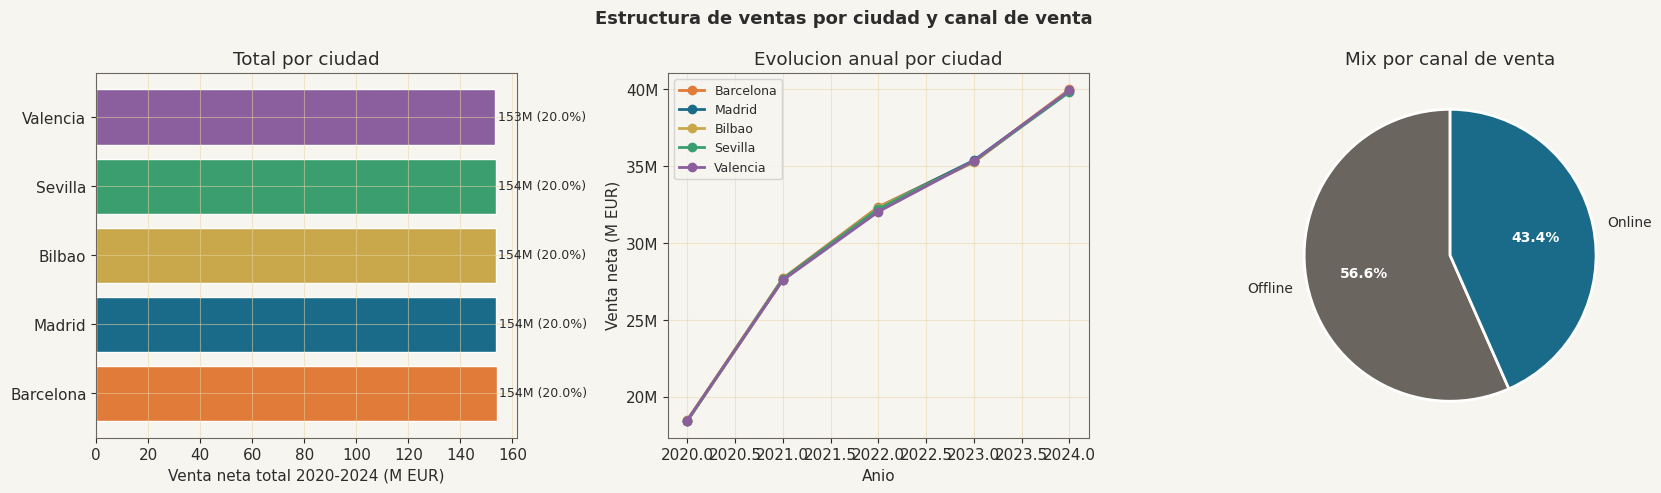

In [7]:
# Aggregar raw por ciudad y canal
ciudad_anio = (
    df_raw.assign(anio=df_raw['fecha_venta'].dt.year)
    .groupby(['anio','ciudad'])['venta_neta_sin_iva_eur'].sum()
    .reset_index()
)
canal_anio = (
    df_raw.assign(anio=df_raw['fecha_venta'].dt.year)
    .groupby(['anio','canal_venta'])['venta_neta_sin_iva_eur'].sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Estructura de ventas por ciudad y canal de venta',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Total por ciudad
ax = axes[0]
tot_ciudad = ciudad_anio.groupby('ciudad')['venta_neta_sin_iva_eur'].sum().sort_values(ascending=False)
ax.barh(tot_ciudad.index, tot_ciudad.values/1e6,
        color=[CIUDAD_COLOR.get(c, KM['warm_gray']) for c in tot_ciudad.index],
        edgecolor='white')
for i, val in enumerate(tot_ciudad.values):
    ax.text(val/1e6+1, i, f'{val/1e6:.0f}M ({val/tot_ciudad.sum()*100:.1f}%)',
            va='center', fontsize=9)
ax.set_xlabel('Venta neta total 2020-2024 (M EUR)')
ax.set_title('Total por ciudad')

# Evolucion anual por ciudad (lineas)
ax2 = axes[1]
for ciudad in tot_ciudad.index:
    datos = ciudad_anio[ciudad_anio['ciudad']==ciudad]
    ax2.plot(datos['anio'], datos['venta_neta_sin_iva_eur']/1e6,
             marker='o', lw=2, color=CIUDAD_COLOR.get(ciudad, KM['warm_gray']),
             label=ciudad)
ax2.set_xlabel('Anio')
ax2.set_ylabel('Venta neta (M EUR)')
ax2.set_title('Evolucion anual por ciudad')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))

# Mix por canal de venta
ax3 = axes[2]
tot_canal = canal_anio.groupby('canal_venta')['venta_neta_sin_iva_eur'].sum()
canal_colors = {'Online': KM['paid_search'], 'Tienda': KM['radio'],
                'ClickCollect': KM['display']}
wedges, texts, autotexts = ax3.pie(
    tot_canal.values,
    labels=tot_canal.index,
    colors=[canal_colors.get(c, KM['warm_gray']) for c in tot_canal.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
ax3.set_title('Mix por canal de venta')

plt.tight_layout()
save_fig('02e_ventas_ciudad_canal')
plt.show()

  Guardado: img\02f_mix_canal_anual.png


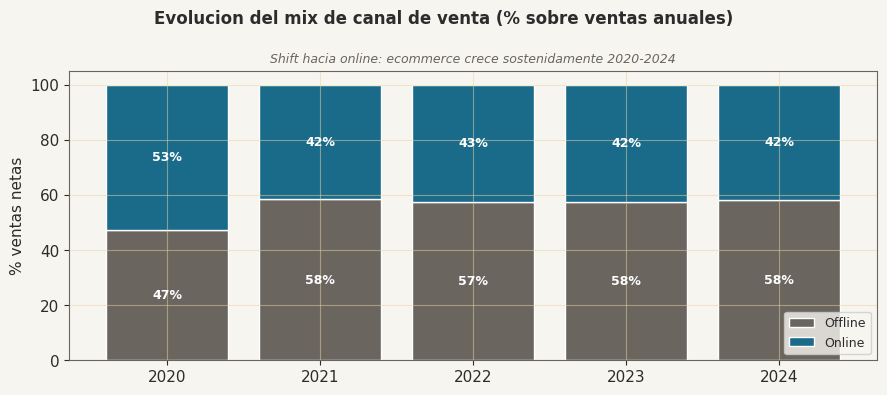

In [8]:
# Evolucion del mix de canal de venta anio a anio
canal_pct = (
    canal_anio.pivot(index='anio', columns='canal_venta', values='venta_neta_sin_iva_eur')
    .div(canal_anio.groupby('anio')['venta_neta_sin_iva_eur'].sum(), axis=0) * 100
)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Evolucion del mix de canal de venta (% sobre ventas anuales)',
             fontsize=12, fontweight='bold', color=KM['charcoal'])
bottom = np.zeros(len(canal_pct))
for col in canal_pct.columns:
    ax.bar(canal_pct.index, canal_pct[col], bottom=bottom,
           label=col, color=canal_colors.get(col, KM['warm_gray']),
           edgecolor='white', linewidth=1)
    for i, (anio, val) in enumerate(zip(canal_pct.index, canal_pct[col])):
        if val > 4:
            ax.text(anio, bottom[i] + val/2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += canal_pct[col].values
ax.set_ylabel('% ventas netas')
ax.set_xticks(canal_pct.index)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 105)
ax.set_title('Shift hacia online: ecommerce crece sostenidamente 2020-2024',
             fontsize=9, color=KM['warm_gray'], style='italic')
plt.tight_layout()
save_fig('02f_mix_canal_anual')
plt.show()

## 7. Top categorias de producto

  Guardado: img\02g_perfil_estacional_yoy.png


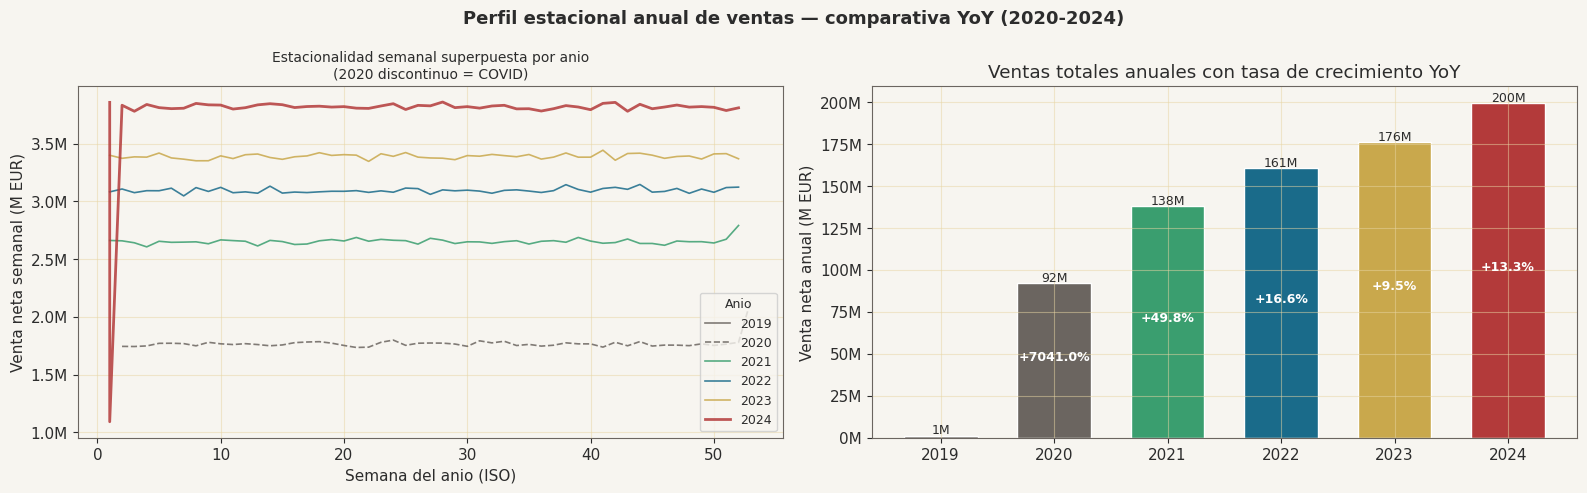

Ventas netas totales por anio:
  2019: 1.3M EUR  (base)
  2020: 92.1M EUR  (+7041.0%)
  2021: 138.0M EUR  (+49.8%)
  2022: 160.9M EUR  (+16.6%)
  2023: 176.2M EUR  (+9.5%)
  2024: 199.6M EUR  (+13.3%)


In [9]:
# Perfil estacional YoY: ventas semanales por semana ISO, una linea por anio
# Sustituye el grafico trivial de categorias (datos sinteticos con 1 sola categoria)

anio_colors = {2020: KM['warm_gray'], 2021: KM['display'], 2022: KM['paid_search'],
               2023: KM['gold'], 2024: KM['negative']}

df_yoy = df_v[['semana_inicio', 'semana_iso', 'anio', 'venta_neta_sin_iva_eur']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Perfil estacional anual de ventas — comparativa YoY (2020-2024)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Panel izquierdo: lineas superpuestas por anio
ax = axes[0]
for anio, grp in df_yoy.groupby('anio'):
    grp_s = grp.sort_values('semana_iso')
    ax.plot(grp_s['semana_iso'], grp_s['venta_neta_sin_iva_eur']/1e6,
            color=anio_colors.get(anio, KM['warm_gray']),
            lw=2 if anio == 2024 else 1.2,
            ls='-' if anio != 2020 else '--',
            alpha=0.85, label=str(anio))
ax.set_xlabel('Semana del anio (ISO)')
ax.set_ylabel('Venta neta semanal (M EUR)')
ax.set_title('Perfil semanal superpuesto por anio')
ax.legend(fontsize=9, title='Anio', title_fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
ax.set_title('Estacionalidad semanal superpuesta por anio\n(2020 discontinuo = COVID)',
             fontsize=10)

# Panel derecho: crecimiento total anual (barras)
ax2 = axes[1]
ventas_anio = df_yoy.groupby('anio')['venta_neta_sin_iva_eur'].sum() / 1e6
crecimiento = ventas_anio.pct_change() * 100
bars = ax2.bar(ventas_anio.index, ventas_anio.values,
               color=[anio_colors.get(a, KM['warm_gray']) for a in ventas_anio.index],
               edgecolor='white', width=0.65)
for bar, val, anio in zip(bars, ventas_anio.values, ventas_anio.index):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.0f}M', ha='center', fontsize=9, color=KM['charcoal'])
    if anio in crecimiento.index and not np.isnan(crecimiento[anio]):
        color_crec = KM['positive'] if crecimiento[anio] >= 0 else KM['negative']
        ax2.text(bar.get_x() + bar.get_width()/2, val/2,
                 f'{crecimiento[anio]:+.1f}%', ha='center', fontsize=9,
                 color='white', fontweight='bold')
ax2.set_ylabel('Venta neta anual (M EUR)')
ax2.set_title('Ventas totales anuales con tasa de crecimiento YoY')
ax2.set_xticks(ventas_anio.index)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))

plt.tight_layout()
save_fig('02g_perfil_estacional_yoy')
plt.show()

print('Ventas netas totales por anio:')
for anio, val in ventas_anio.items():
    crec = f'{crecimiento[anio]:+.1f}%' if anio in crecimiento.index and not np.isnan(crecimiento[anio]) else 'base'
    print(f'  {anio}: {val:.1f}M EUR  ({crec})')

## 8. Inversion publicitaria — Analisis detallado

  Guardado: img\02h_inversion_estacional_mix.png


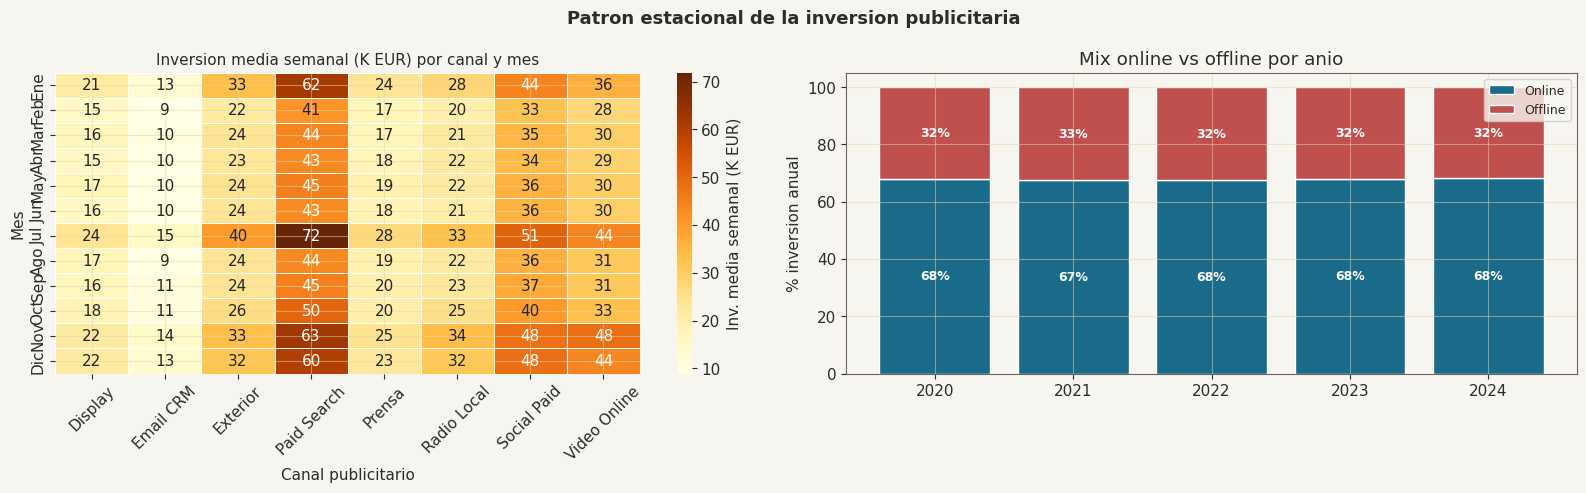

In [10]:
# Heatmap: inversion media por canal x mes
inv_heatmap = df_i.copy()
inv_heatmap['mes'] = inv_heatmap['semana_inicio'].dt.month
hm_data = inv_heatmap.groupby('mes')[CANALES].mean() / 1e3  # en miles EUR
hm_data.index = MESES

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Patron estacional de la inversion publicitaria',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Heatmap
ax = axes[0]
sns.heatmap(hm_data, ax=ax, cmap='YlOrBr', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Inv. media semanal (K EUR)'})
ax.set_title('Inversion media semanal (K EUR) por canal y mes', fontsize=11)
ax.set_xlabel('Canal publicitario')
ax.set_ylabel('Mes')
ax.tick_params(axis='x', rotation=45)

# Mix online vs offline por anio
ax2 = axes[1]
df_i_copy = df_i.copy()
online_cols  = ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM']
offline_cols = ['Radio Local', 'Exterior', 'Prensa']
df_i_copy['inv_online']  = df_i_copy[online_cols].sum(axis=1)
df_i_copy['inv_offline'] = df_i_copy[offline_cols].sum(axis=1)
mix_anio = df_i_copy.groupby('anio')[['inv_online','inv_offline']].sum() / 1e6
mix_pct = mix_anio.div(mix_anio.sum(axis=1), axis=0) * 100

ax2.bar(mix_pct.index, mix_pct['inv_online'],  label='Online',  color=KM['paid_search'], edgecolor='white')
ax2.bar(mix_pct.index, mix_pct['inv_offline'], bottom=mix_pct['inv_online'],
        label='Offline', color=KM['radio'], edgecolor='white')
for anio in mix_pct.index:
    on_pct  = mix_pct.loc[anio,'inv_online']
    off_pct = mix_pct.loc[anio,'inv_offline']
    ax2.text(anio, on_pct/2,          f'{on_pct:.0f}%',  ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    ax2.text(anio, on_pct + off_pct/2, f'{off_pct:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax2.set_ylabel('% inversion anual')
ax2.set_title('Mix online vs offline por anio')
ax2.legend(fontsize=9)
ax2.set_xticks(mix_pct.index)

plt.tight_layout()
save_fig('02h_inversion_estacional_mix')
plt.show()

## 9. Correlacion preliminar: inversion vs ventas (sin lag)

  Guardado: img\02i_correlacion_preliminar.png


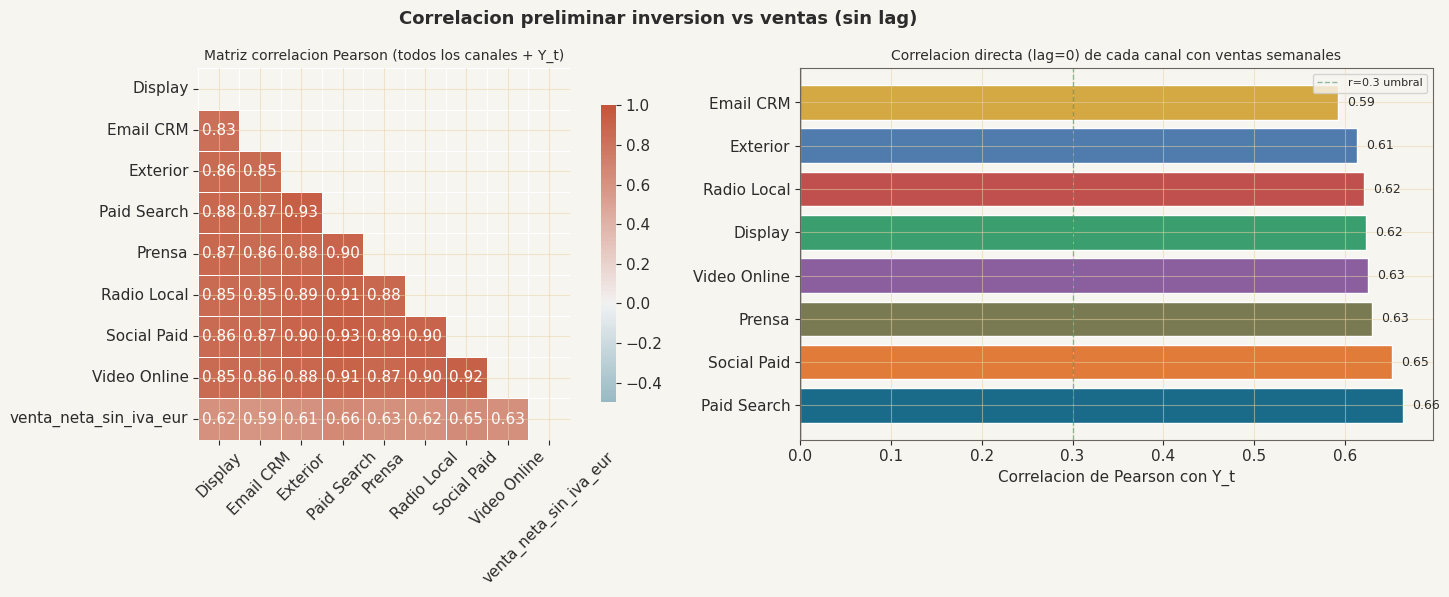

ADVERTENCIA: correlaciones sin lag subestiman canales offline (Radio, Exterior, Prensa).
La seccion siguiente muestra la correlacion con lags 0-4 semanas.


In [11]:
# Matriz de correlacion de Pearson
corr_cols = CANALES + ['venta_neta_sin_iva_eur']
corr_matrix = df_eda[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlacion preliminar inversion vs ventas (sin lag)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Heatmap completo
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            vmin=-0.5, vmax=1, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz correlacion Pearson (todos los canales + Y_t)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Barras: correlacion de cada canal con ventas (de mayor a menor)
ax2 = axes[1]
corr_ventas = corr_matrix['venta_neta_sin_iva_eur'].drop('venta_neta_sin_iva_eur').sort_values(ascending=False)
colors_bar = [KM['positive'] if v > 0.3 else (KM['neutral'] if v > 0 else KM['negative'])
              for v in corr_ventas.values]
bars = ax2.barh(corr_ventas.index, corr_ventas.values,
                color=[CANAL_COLOR.get(c, KM['warm_gray']) for c in corr_ventas.index],
                edgecolor='white')
ax2.axvline(0, color=KM['charcoal'], lw=1)
ax2.axvline(0.3, color=KM['positive'], lw=1, ls='--', alpha=0.5, label='r=0.3 umbral')
for bar, val in zip(bars, corr_ventas.values):
    ax2.text(val + 0.01 if val >= 0 else val - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax2.set_xlabel('Correlacion de Pearson con Y_t')
ax2.set_title('Correlacion directa (lag=0) de cada canal con ventas semanales', fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
save_fig('02i_correlacion_preliminar')
plt.show()

print('ADVERTENCIA: correlaciones sin lag subestiman canales offline (Radio, Exterior, Prensa).')
print('La seccion siguiente muestra la correlacion con lags 0-4 semanas.')

## 10. Cross-correlation por lag — Justificacion empirica de la tabla Lag/Alpha (Fase 3)

Para cada canal m, calculamos la correlacion de Pearson entre `inversion_{t-k,m}` y `ventas_t` para k en {0, 1, 2, 3, 4}. El lag con correlacion maxima sugiere el desfase optimo de ese canal. Esto **justifica empiricamente** los valores de la tabla de parametros usada en la Fase 3.

  Guardado: img\02j_cross_correlation_lag.png


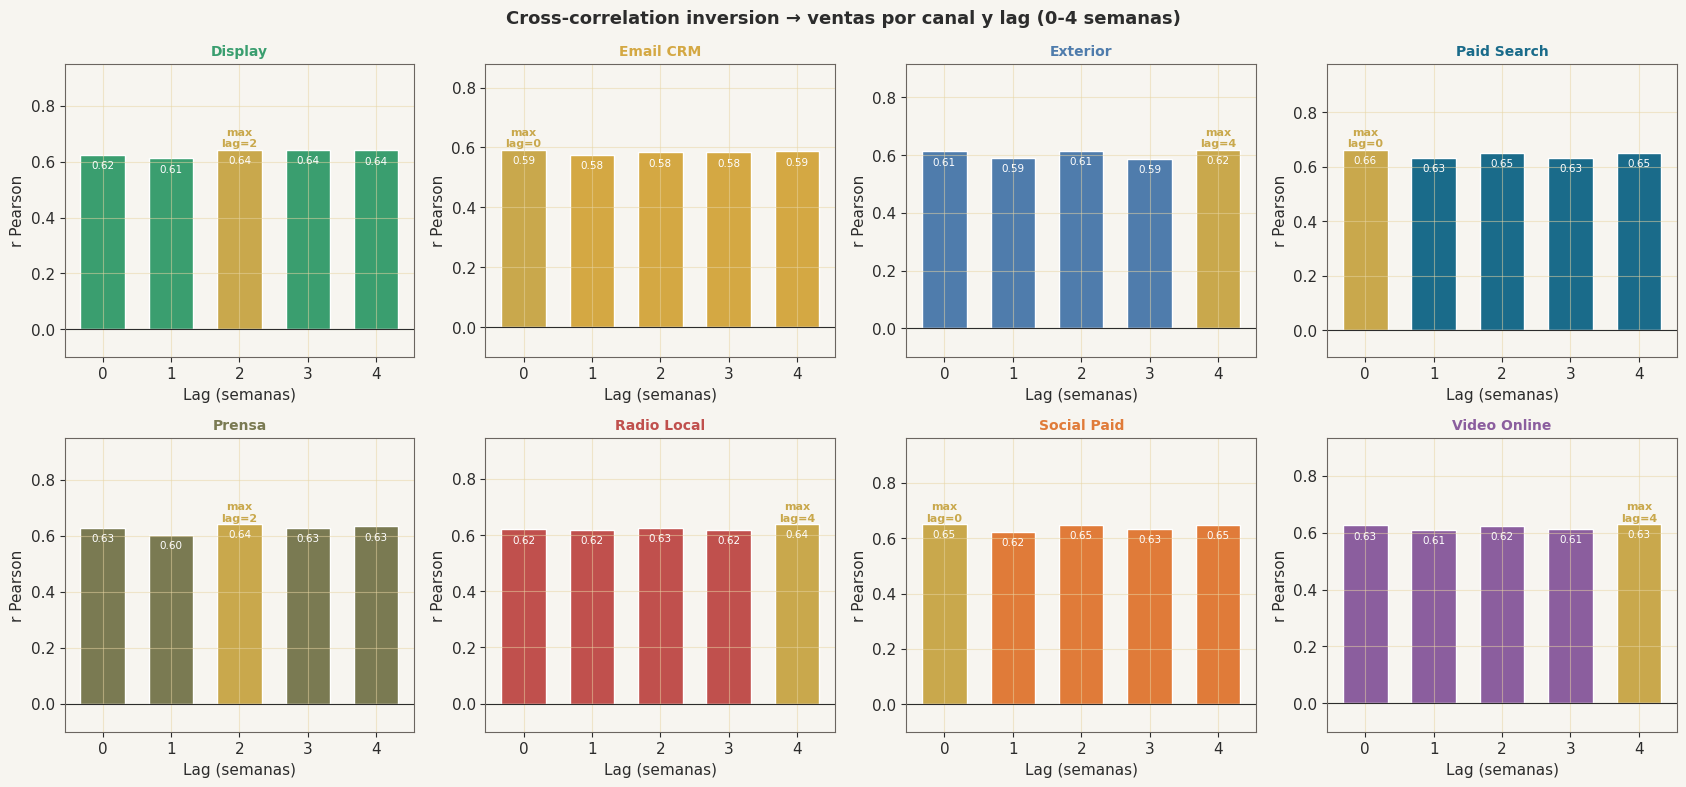

LAG OPTIMO EMPIRICO POR CANAL (maximo r Pearson):
  Display        : lag=2 sem  (r=0.644)
  Email CRM      : lag=0 sem  (r=0.592)
  Exterior       : lag=4 sem  (r=0.619)
  Paid Search    : lag=0 sem  (r=0.663)
  Prensa         : lag=2 sem  (r=0.642)
  Radio Local    : lag=4 sem  (r=0.639)
  Social Paid    : lag=0 sem  (r=0.651)
  Video Online   : lag=4 sem  (r=0.630)


In [12]:
MAX_LAG = 5
y_t = df_eda['venta_neta_sin_iva_eur'].values

cross_corr = {}
for canal in CANALES:
    x = df_eda[canal].values
    corrs = []
    for lag in range(MAX_LAG):
        if lag == 0:
            r, _ = stats.pearsonr(x, y_t)
        else:
            r, _ = stats.pearsonr(x[:-lag], y_t[lag:])
        corrs.append(r)
    cross_corr[canal] = corrs

df_cc = pd.DataFrame(cross_corr, index=[f'lag={k}' for k in range(MAX_LAG)])

fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=False)
fig.suptitle('Cross-correlation inversion → ventas por canal y lag (0-4 semanas)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

for ax, canal in zip(axes.flatten(), CANALES):
    lags = range(MAX_LAG)
    corrs = df_cc[canal].values
    best_lag = int(np.argmax(corrs))
    bar_colors = [KM['gold'] if i == best_lag else CANAL_COLOR.get(canal, KM['warm_gray'])
                  for i in lags]
    ax.bar(lags, corrs, color=bar_colors, edgecolor='white', width=0.65)
    ax.axhline(0, color=KM['charcoal'], lw=0.8)
    ax.set_title(canal, fontsize=10, color=CANAL_COLOR.get(canal, KM['charcoal']), fontweight='bold')
    ax.set_xlabel('Lag (semanas)')
    ax.set_ylabel('r Pearson')
    ax.set_xticks(list(lags))
    ax.set_ylim(-0.1, max(corrs) * 1.4 + 0.05)
    ax.text(best_lag, corrs[best_lag] + 0.01, f'max\nlag={best_lag}',
            ha='center', fontsize=8, color=KM['gold'], fontweight='bold')
    for i, r in enumerate(corrs):
        ax.text(i, max(r - 0.02, -0.08), f'{r:.2f}',
                ha='center', va='top', fontsize=7.5, color='white' if r > 0.05 else KM['charcoal'])

plt.tight_layout()
save_fig('02j_cross_correlation_lag')
plt.show()

print('LAG OPTIMO EMPIRICO POR CANAL (maximo r Pearson):')
for canal in CANALES:
    best = int(np.argmax(df_cc[canal].values))
    r_max = df_cc[canal].values[best]
    print(f'  {canal:15s}: lag={best} sem  (r={r_max:.3f})')

## 11. Trafico como variable mediadora (SOLO EDA)

  Guardado: img\02k_trafico_mediador.png


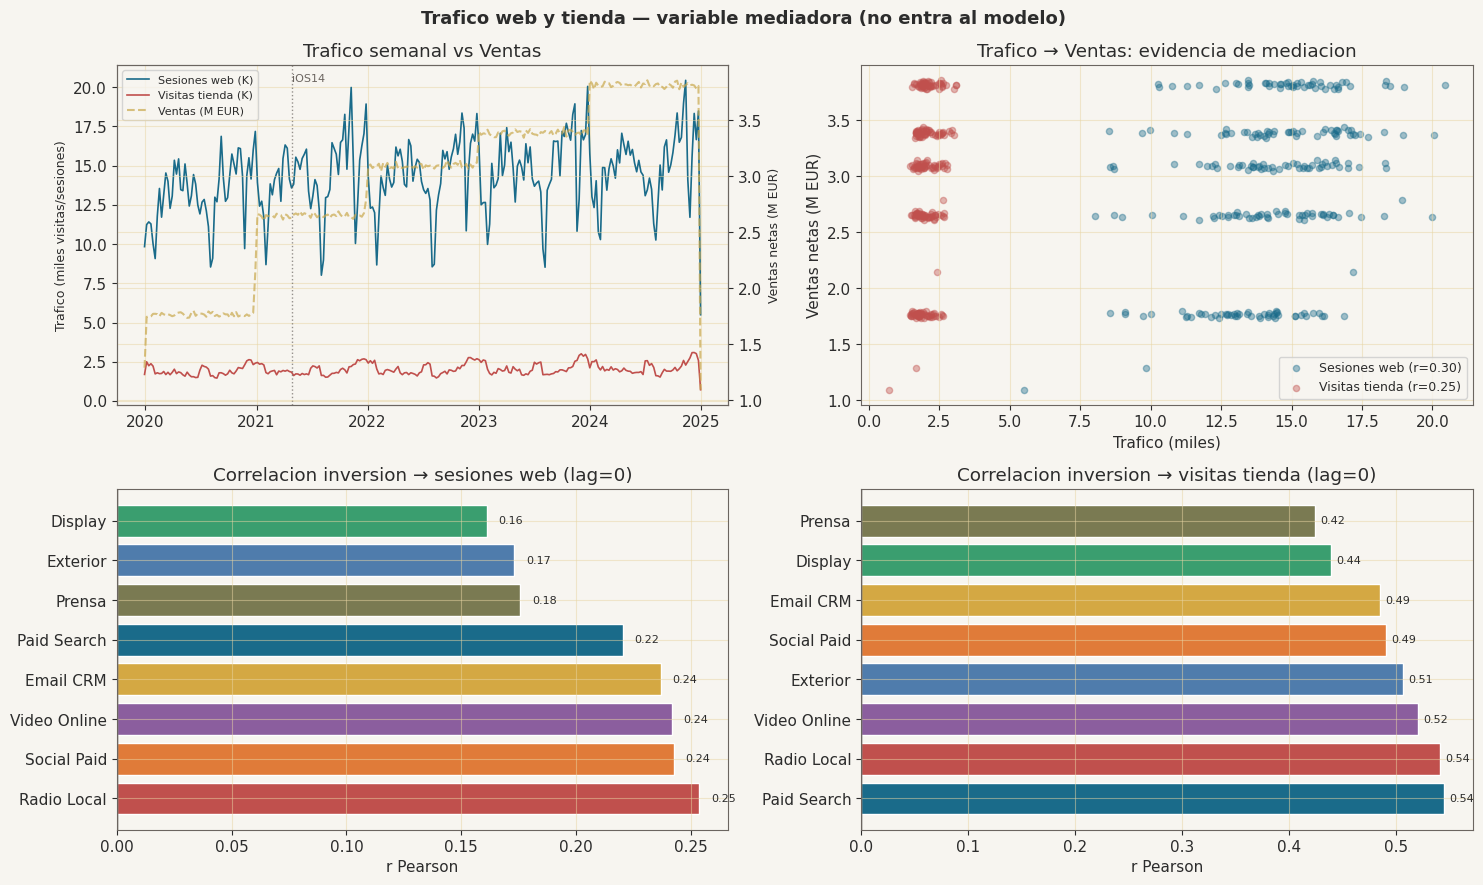

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Trafico web y tienda — variable mediadora (no entra al modelo)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Serie temporal trafico vs ventas (doble eje)
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(df_eda['semana_inicio'], df_eda['sesiones_web']/1e3, color=KM['paid_search'], lw=1.2, label='Sesiones web (K)')
ax.plot(df_eda['semana_inicio'], df_eda['visitas_tienda']/1e3, color=KM['radio'], lw=1.2, label='Visitas tienda (K)')
ax2.plot(df_eda['semana_inicio'], df_eda['venta_neta_sin_iva_eur']/1e6, color=KM['gold'], lw=1.5, ls='--', alpha=0.7, label='Ventas (M EUR)')
ax.axvline(pd.Timestamp('2021-04-26'), color=KM['warm_gray'], lw=1, ls=':', alpha=0.7)
ax.text(pd.Timestamp('2021-04-26'), ax.get_ylim()[1]*0.95, 'iOS14', fontsize=8, color=KM['warm_gray'])
ax.set_ylabel('Trafico (miles visitas/sesiones)', fontsize=9)
ax2.set_ylabel('Ventas netas (M EUR)', fontsize=9)
ax.set_title('Trafico semanal vs Ventas')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper left')

# Scatter trafico → ventas
ax = axes[0, 1]
r_web,  _ = stats.pearsonr(df_eda['sesiones_web'].dropna(), df_eda.loc[df_eda['sesiones_web'].notna(),'venta_neta_sin_iva_eur'])
r_tien, _ = stats.pearsonr(df_eda['visitas_tienda'].dropna(), df_eda.loc[df_eda['visitas_tienda'].notna(),'venta_neta_sin_iva_eur'])
ax.scatter(df_eda['sesiones_web']/1e3,   df_eda['venta_neta_sin_iva_eur']/1e6, alpha=0.4, s=20,
           color=KM['paid_search'], label=f'Sesiones web (r={r_web:.2f})')
ax.scatter(df_eda['visitas_tienda']/1e3, df_eda['venta_neta_sin_iva_eur']/1e6, alpha=0.4, s=20,
           color=KM['radio'],       label=f'Visitas tienda (r={r_tien:.2f})')
ax.set_xlabel('Trafico (miles)')
ax.set_ylabel('Ventas netas (M EUR)')
ax.set_title('Trafico → Ventas: evidencia de mediacion')
ax.legend(fontsize=9)

# Correlacion publicidad → trafico web
ax = axes[1, 0]
corr_inv_web = {c: stats.pearsonr(df_eda[c].dropna(), df_eda.loc[df_eda[c].notna(),'sesiones_web'])[0] for c in CANALES}
sorted_corr = sorted(corr_inv_web.items(), key=lambda x: x[1], reverse=True)
canales_s, corrs_s = zip(*sorted_corr)
ax.barh(canales_s, corrs_s, color=[CANAL_COLOR.get(c,KM['warm_gray']) for c in canales_s], edgecolor='white')
ax.axvline(0, color=KM['charcoal'], lw=1)
ax.set_xlabel('r Pearson')
ax.set_title('Correlacion inversion → sesiones web (lag=0)')
for i, r in enumerate(corrs_s):
    ax.text(r + 0.005 if r >= 0 else r - 0.005, i, f'{r:.2f}',
            va='center', ha='left' if r >= 0 else 'right', fontsize=8)

# Correlacion publicidad → trafico tienda
ax = axes[1, 1]
corr_inv_tien = {c: stats.pearsonr(df_eda[c].dropna(), df_eda.loc[df_eda[c].notna(),'visitas_tienda'])[0] for c in CANALES}
sorted_corr2 = sorted(corr_inv_tien.items(), key=lambda x: x[1], reverse=True)
canales_s2, corrs_s2 = zip(*sorted_corr2)
ax.barh(canales_s2, corrs_s2, color=[CANAL_COLOR.get(c,KM['warm_gray']) for c in canales_s2], edgecolor='white')
ax.axvline(0, color=KM['charcoal'], lw=1)
ax.set_xlabel('r Pearson')
ax.set_title('Correlacion inversion → visitas tienda (lag=0)')
for i, r in enumerate(corrs_s2):
    ax.text(r + 0.005 if r >= 0 else r - 0.005, i, f'{r:.2f}',
            va='center', ha='left' if r >= 0 else 'right', fontsize=8)

plt.tight_layout()
save_fig('02k_trafico_mediador')
plt.show()

## 12. Degradacion del entorno de datos post-iOS 14

  Guardado: img\02l_ios14_degradacion.png


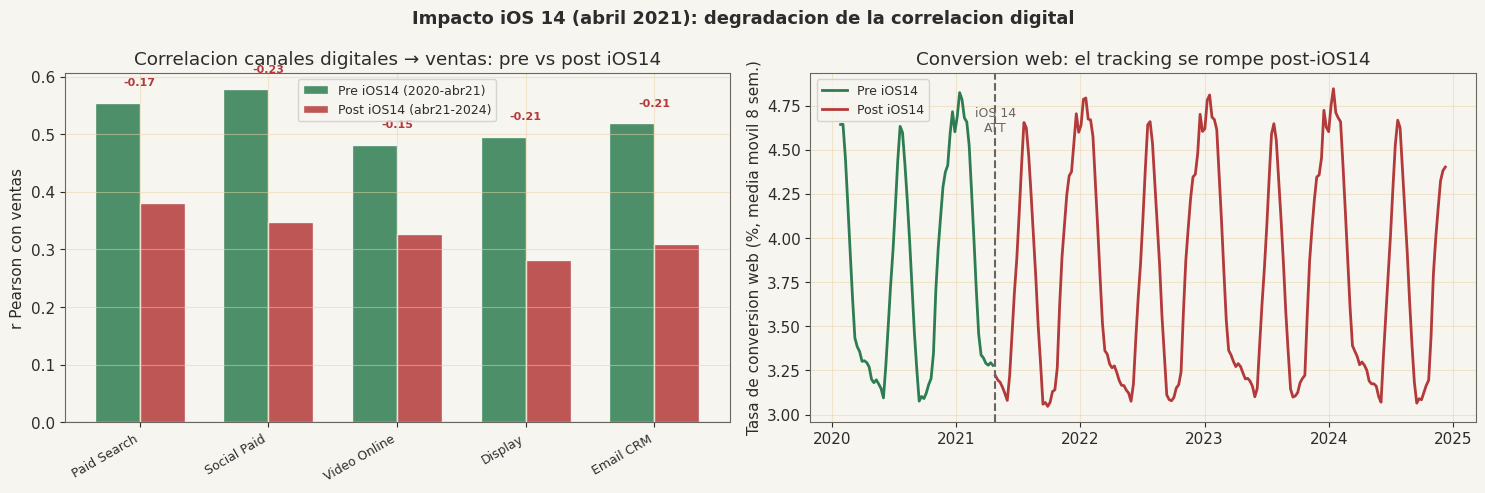

DEGRADACION DE CORRELACION POST-iOS14 (canales digitales):
  Paid Search    : pre=+0.555  post=+0.381  delta=-0.174
  Social Paid    : pre=+0.578  post=+0.348  delta=-0.229
  Video Online   : pre=+0.482  post=+0.327  delta=-0.155
  Display        : pre=+0.496  post=+0.282  delta=-0.214
  Email CRM      : pre=+0.519  post=+0.309  delta=-0.210

CONCLUSION: La degradacion del tracking individual post-iOS14 justifica el MMM
como herramienta de atribucion agregada e independiente del tracking pixel.


In [14]:
IOS14 = pd.Timestamp('2021-04-26')
CANALES_DIGITAL = ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM']

pre  = df_eda[df_eda['semana_inicio'] <  IOS14].copy()
post = df_eda[df_eda['semana_inicio'] >= IOS14].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Impacto iOS 14 (abril 2021): degradacion de la correlacion digital',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Correlacion de canales digitales con ventas: pre vs post iOS14
ax = axes[0]
x = np.arange(len(CANALES_DIGITAL))
w = 0.35
r_pre  = [stats.pearsonr(pre[c],  pre['venta_neta_sin_iva_eur'])[0]  for c in CANALES_DIGITAL]
r_post = [stats.pearsonr(post[c], post['venta_neta_sin_iva_eur'])[0] for c in CANALES_DIGITAL]

ax.bar(x - w/2, r_pre,  w, label='Pre iOS14 (2020-abr21)',  color=KM['positive'],  edgecolor='white', alpha=0.85)
ax.bar(x + w/2, r_post, w, label='Post iOS14 (abr21-2024)', color=KM['negative'], edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CANALES_DIGITAL, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('r Pearson con ventas')
ax.set_title('Correlacion canales digitales → ventas: pre vs post iOS14')
ax.legend(fontsize=9)
ax.axhline(0, color=KM['charcoal'], lw=0.8)
for i, (rp, ro) in enumerate(zip(r_pre, r_post)):
    delta = ro - rp
    color = KM['negative'] if delta < 0 else KM['positive']
    ax.text(i, max(rp, ro) + 0.03, f'{delta:+.2f}', ha='center', fontsize=8, color=color, fontweight='bold')

# Evolucion rolling de conversion web: pre vs post (visualiza la degradacion)
ax2 = axes[1]
conv_rol = df_eda.set_index('semana_inicio')['conv_web'].rolling(8, center=True).mean()
ax2.plot(conv_rol.index[conv_rol.index < IOS14], conv_rol[conv_rol.index < IOS14] * 100,
         color=KM['positive'], lw=2, label='Pre iOS14')
ax2.plot(conv_rol.index[conv_rol.index >= IOS14], conv_rol[conv_rol.index >= IOS14] * 100,
         color=KM['negative'], lw=2, label='Post iOS14')
ax2.axvline(IOS14, color=KM['warm_gray'], lw=1.5, ls='--')
ax2.text(IOS14, conv_rol.max()*100*0.95, 'iOS 14\nATT',
         fontsize=9, color=KM['warm_gray'], ha='center')
ax2.set_ylabel('Tasa de conversion web (%, media movil 8 sem.)')
ax2.set_title('Conversion web: el tracking se rompe post-iOS14')
ax2.legend(fontsize=9)

plt.tight_layout()
save_fig('02l_ios14_degradacion')
plt.show()

print('DEGRADACION DE CORRELACION POST-iOS14 (canales digitales):')
for canal, rp, ro in zip(CANALES_DIGITAL, r_pre, r_post):
    delta = ro - rp
    print(f'  {canal:15s}: pre={rp:+.3f}  post={ro:+.3f}  delta={delta:+.3f}')
print()
print('CONCLUSION: La degradacion del tracking individual post-iOS14 justifica el MMM')
print('como herramienta de atribucion agregada e independiente del tracking pixel.')

## 13. Resumen de insights para la Fase 3

In [15]:
print('=' * 70)
print('INSIGHTS CLAVE DE LA EDA — IMPLICACIONES PARA FEATURE ENGINEERING')
print('=' * 70)

print()
print('1. ESTACIONALIDAD')
print('   - Pico en Ene-Feb (rebajas) y Nov-Dic (BF + Navidad)')
print('   - Valles en verano (Jul-Ago): comportamiento inverso al comercio tipico')
print('   => Variables exogenas obligatorias: black_friday_flag, navidad_flag,'
      ' rebajas_flag, semana_santa_flag')

print()
print('2. LAGS EMPIRICOS (cross-correlation max Pearson):')
for canal in CANALES:
    best = int(np.argmax(df_cc[canal].values))
    r_max = df_cc[canal].values[best]
    print(f'   {canal:15s}: lag={best} sem  r={r_max:.3f}')

print()
print('3. MULTICOLINEALIDAD — canales con correlacion alta entre si (r>0.6):')
for i, c1 in enumerate(CANALES):
    for c2 in CANALES[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.6:
            print(f'   {c1} <-> {c2}: r={r:.2f}  => Ridge/ElasticNet manejara esto')

print()
print('4. TRAFICO COMO MEDIADOR')
print(f'   - r(sesiones_web, ventas)    = {r_web:.2f}')
print(f'   - r(visitas_tienda, ventas)  = {r_tien:.2f}')
print('   => Confirma mediacion. No entra al modelo de regresion.')

print()
print('5. iOS14: degradacion de correlacion digital confirmada')
print('   => Considerar dummy incidencia_ecommerce_flag como variable exogena')

print()
print('6. SHIFT OMNICANAL')
print('   - Online crece de anio en anio')
print('   => Incluir incidencia_ecommerce_flag como control estructural')

INSIGHTS CLAVE DE LA EDA — IMPLICACIONES PARA FEATURE ENGINEERING

1. ESTACIONALIDAD
   - Pico en Ene-Feb (rebajas) y Nov-Dic (BF + Navidad)
   - Valles en verano (Jul-Ago): comportamiento inverso al comercio tipico
   => Variables exogenas obligatorias: black_friday_flag, navidad_flag, rebajas_flag, semana_santa_flag

2. LAGS EMPIRICOS (cross-correlation max Pearson):
   Display        : lag=2 sem  r=0.644
   Email CRM      : lag=0 sem  r=0.592
   Exterior       : lag=4 sem  r=0.619
   Paid Search    : lag=0 sem  r=0.663
   Prensa         : lag=2 sem  r=0.642
   Radio Local    : lag=4 sem  r=0.639
   Social Paid    : lag=0 sem  r=0.651
   Video Online   : lag=4 sem  r=0.630

3. MULTICOLINEALIDAD — canales con correlacion alta entre si (r>0.6):
   Display <-> Email CRM: r=0.83  => Ridge/ElasticNet manejara esto
   Display <-> Exterior: r=0.86  => Ridge/ElasticNet manejara esto
   Display <-> Paid Search: r=0.88  => Ridge/ElasticNet manejara esto
   Display <-> Prensa: r=0.87  => Ridge/